### Khai báo thư viện và đường dẫn

In [ ]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

# Các file đã tải về (trong thư mục data/images)
image_folder = '../data/images' 
image_files = [f for f in os.listdir(image_folder) if f.endswith(('.jpeg', '.jpg', '.png'))]
sample_path = os.path.join(image_folder, image_files[0]) # Chọn ảnh đầu tiên để demo

### Thực hiện Loading và Resizing

In [ ]:
def load_and_resize(image_path, target_size):
    """
    Thực hiện nạp ảnh và thay đổi kích thước.
    Output: ảnh gốc và ảnh đã resize.
    """
    img = cv2.imread(image_path)
    if img is None:
        return None, None
    
    # Thực hiện resize
    resized_img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
    return img, resized_img

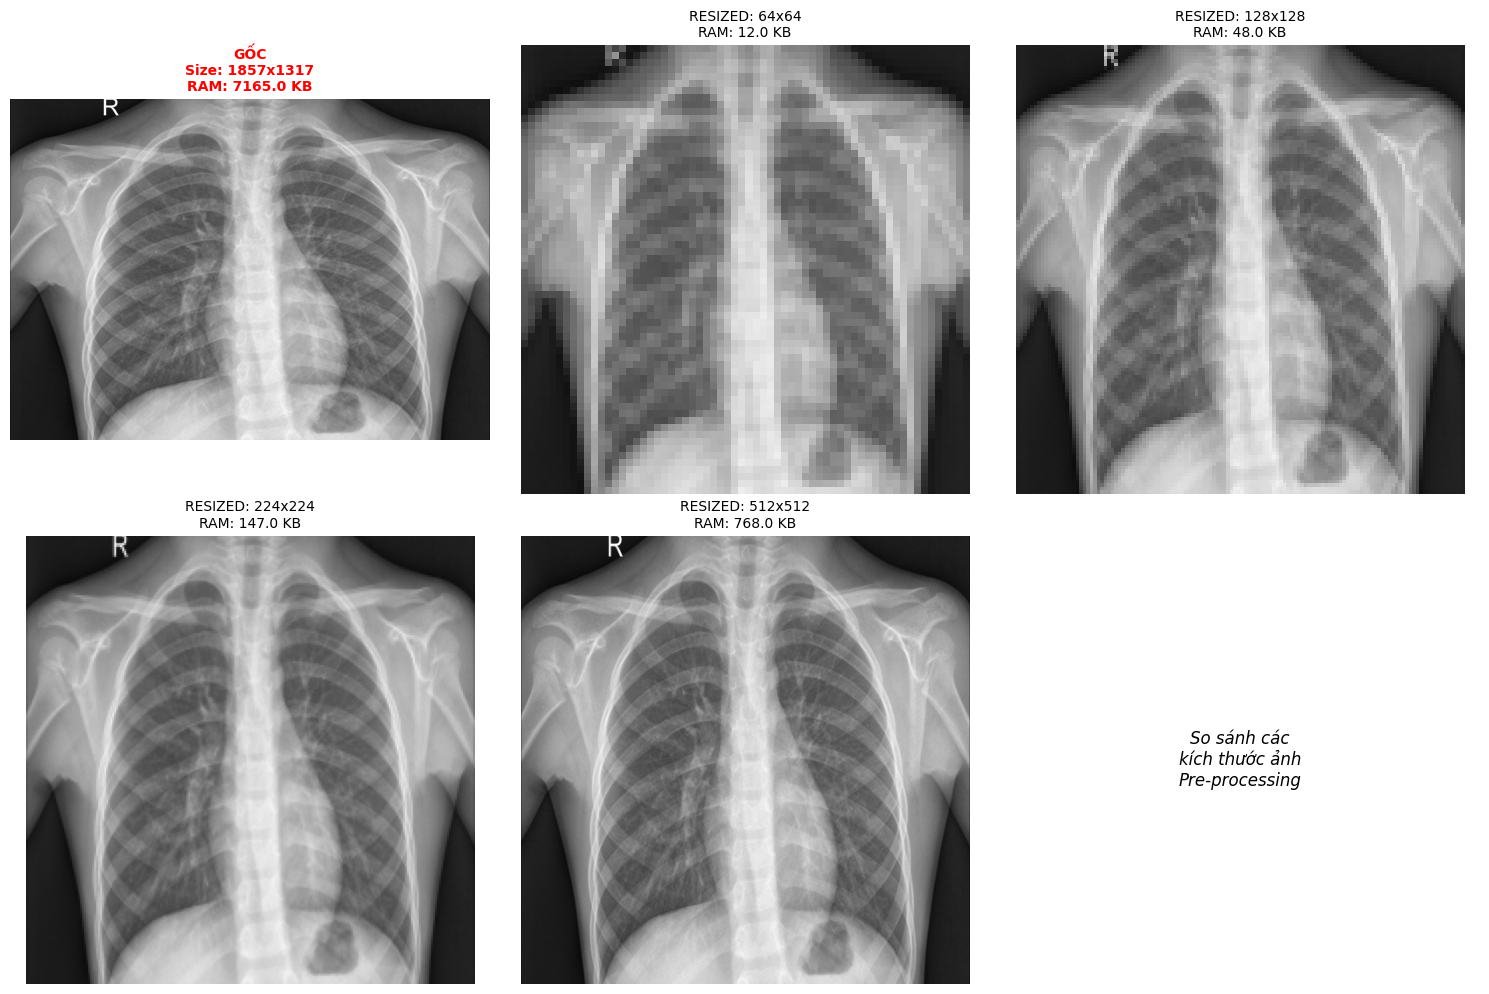

In [3]:
sizes = [(64, 64), (128, 128), (224, 224), (512, 512)]
# Lấy ảnh gốc để chuẩn bị hiển thị
original_img = cv2.imread(sample_path)
original_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

# Tạo khung hình (Figure) với bố cục lưới 2 hàng, 3 cột
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten() # Trải phẳng mảng axes để dễ truy cập bằng chỉ số 0, 1, 2...

# 1. Hiển thị ảnh Gốc vào ô đầu tiên
axes[0].imshow(original_rgb)
axes[0].set_title(f"GỐC\nSize: {original_img.shape[1]}x{original_img.shape[0]}\nRAM: {original_img.nbytes/1024:.1f} KB", 
                  fontsize=10, fontweight='bold', color='red')
axes[0].axis('off')

# 2. Lặp qua các size và hiển thị vào các ô tiếp theo
for i, size in enumerate(sizes):
    # Gọi hàm xử lý đã viết ở Cell 1
    _, resized = load_and_resize(sample_path, size)
    resized_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
    
    ax = axes[i+1] # i+1 vì ô 0 đã dành cho ảnh gốc
    ax.imshow(resized_rgb)
    ax.set_title(f"RESIZED: {size[0]}x{size[1]}\nRAM: {resized.nbytes/1024:.1f} KB", fontsize=10)
    ax.axis('off')

# 3. Ô cuối cùng (nếu thừa) có thể để trống hoặc ghi chú
axes[5].axis('off')
axes[5].text(0.5, 0.5, 'So sánh các\nkích thước ảnh\nPre-processing', 
             ha='center', va='center', fontsize=12, style='italic')

plt.tight_layout()
plt.show()

### Grayscale Conversion

In [4]:
def convert_to_grayscale(img_bgr):
    """
    Chuyển đổi ảnh từ BGR sang Grayscale.
    """
    if img_bgr is None:
        return None
    
    gray_img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    return gray_img

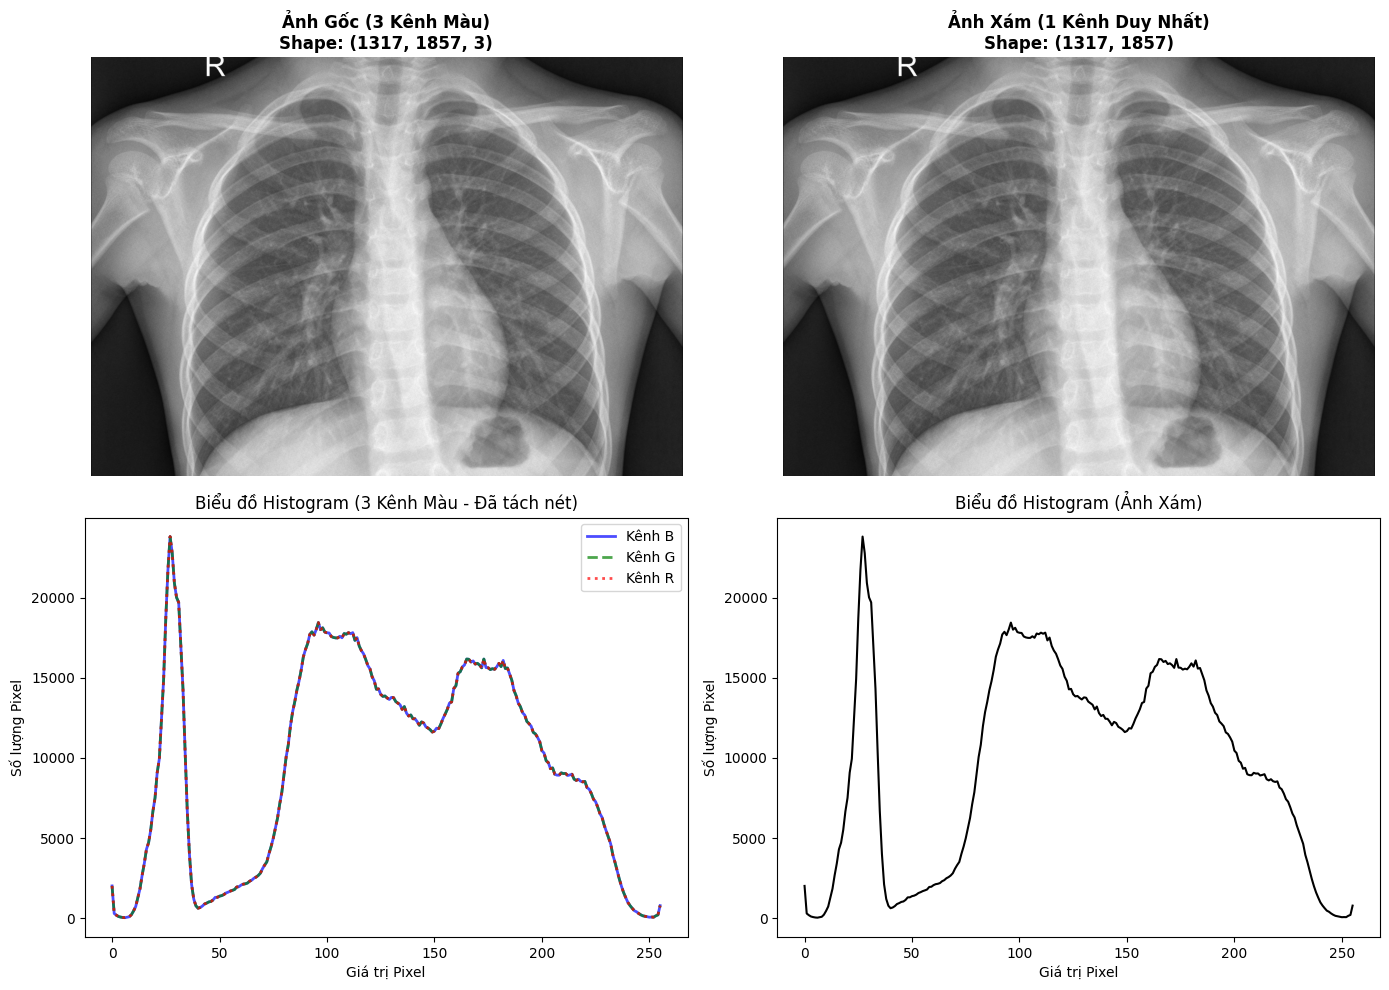

In [ ]:
# 1. Thực hiện chuyển đổi
gray_img = convert_to_grayscale(original_img)

# 2. Trực quan hóa
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

# So sánh hình ảnh
# Ảnh Gốc (RGB)
axes[0, 0].imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title(f"Ảnh Gốc (3 Kênh Màu)\nShape: {original_img.shape}", fontweight='bold')
axes[0, 0].axis('off')

# Ảnh Xám (Grayscale)
axes[0, 1].imshow(gray_img, cmap='gray')
axes[0, 1].set_title(f"Ảnh Xám (1 Kênh Duy Nhất)\nShape: {gray_img.shape}", fontweight='bold')
axes[0, 1].axis('off')

# Phân tích Histogram (Information Retention)

styles = ['-', '--', ':'] # Nét liền, nét đứt lớn, nét chấm điểm
colors = ('b', 'g', 'r')

for i, col in enumerate(colors):
    hist = cv2.calcHist([original_img], [i], None, [256], [0, 256])
    # Sử dụng linewidth và linestyle để phân biệt
    axes[1, 0].plot(hist, color=col, label=f'Kênh {col.upper()}', 
                    linestyle=styles[i], linewidth=2, alpha=0.7)

axes[1, 0].set_title("Biểu đồ Histogram (3 Kênh Màu - Đã tách nét)")
axes[1, 0].set_xlabel("Giá trị Pixel")
axes[1, 0].set_ylabel("Số lượng Pixel")
axes[1, 0].legend()

# Histogram ảnh xám
hist_gray = cv2.calcHist([gray_img], [0], None, [256], [0, 256])
axes[1, 1].plot(hist_gray, color='black')
axes[1, 1].set_title("Biểu đồ Histogram (Ảnh Xám)")
axes[1, 1].set_xlabel("Giá trị Pixel")
axes[1, 1].set_ylabel("Số lượng Pixel")

plt.tight_layout()
plt.show()

### Normalization

In [6]:
def apply_normalization(img_gray):
    """
    Thực hiện 3 kỹ thuật chuẩn hóa khác nhau.
    """
    # 1. Scaling to [0, 1]
    norm_01 = img_gray.astype(np.float32) / 255.0
    
    # 2. Scaling to [-1, 1]
    norm_minus1_1 = (img_gray.astype(np.float32) / 127.5) - 1.0
    
    # 3. Standardization (Zero mean, Unit variance)
    mean = np.mean(img_gray)
    std = np.std(img_gray)
    standardized = (img_gray.astype(np.float32) - mean) / std
    
    return norm_01, norm_minus1_1, standardized

BẢNG SO SÁNH THỐNG KÊ CHI TIẾT:


,Metric,Original (0-255),"Min-Max [0, 1]","Min-Max [-1, 1]",Standardization
0,Min,0.000000,0.00000,-1.000000,-2.294115e+00
1,Max,255.000000,1.00000,1.000000,2.171576e+00
2,Mean,130.998608,0.51372,0.027440,-1.745046e-16
3,Std Dev,57.102032,0.22393,0.447859,1.000000e+00


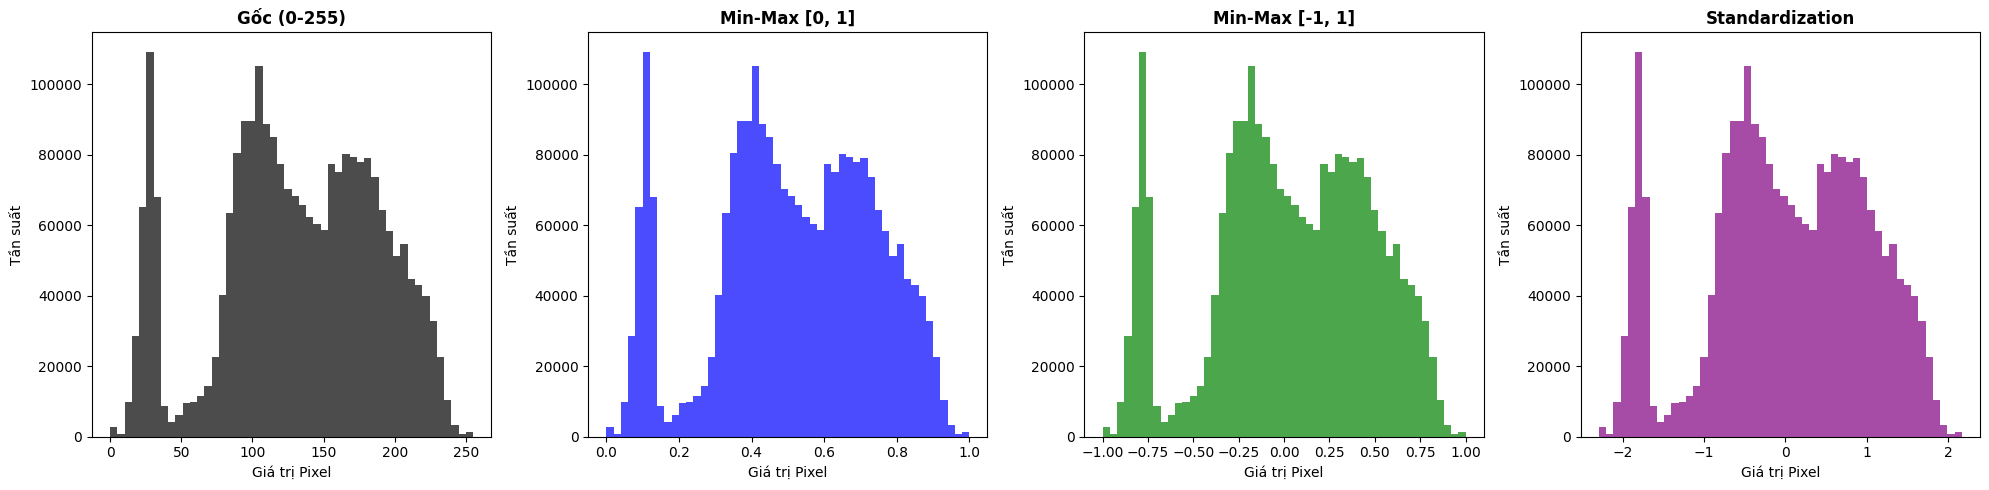

In [ ]:
import pandas as pd 

# Thực thi chuẩn hóa trên ảnh xám đã có từ bước trước
norm_01, norm_m11, standardized = apply_normalization(gray_img)

# 1. Thu thập dữ liệu thống kê để phân tích
stats = {
    "Metric": ["Min", "Max", "Mean", "Std Dev"],
    "Original (0-255)": [gray_img.min(), gray_img.max(), gray_img.mean(), gray_img.std()],
    "Min-Max [0, 1]": [norm_01.min(), norm_01.max(), norm_01.mean(), norm_01.std()],
    "Min-Max [-1, 1]": [norm_m11.min(), norm_m11.max(), norm_m11.mean(), norm_m11.std()],
    "Standardization": [standardized.min(), standardized.max(), standardized.mean(), standardized.std()]
}
df_stats = pd.DataFrame(stats)
print("BẢNG SO SÁNH THỐNG KÊ CHI TIẾT:")
display(df_stats)

# 2. Trực quan hóa phân phối dữ liệu 
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(20, 5))

titles = ["Gốc (0-255)", "Min-Max [0, 1]", "Min-Max [-1, 1]", "Standardization"]
data_list = [gray_img, norm_01, norm_m11, standardized]
colors = ['black', 'blue', 'green', 'purple']

for i, data in enumerate(data_list):
    axes[i].hist(data.flatten(), bins=50, color=colors[i], alpha=0.7)
    axes[i].set_title(titles[i], fontweight='bold')
    axes[i].set_xlabel("Giá trị Pixel")
    axes[i].set_ylabel("Tần suất")

plt.tight_layout()
plt.show()

### Edge Detection

In [23]:
def apply_edge_detection(img_gray):
    # 1. Sobel: Tính đạo hàm theo X và Y rồi kết hợp lại
    sobel_x = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)
    sobel_combined = cv2.magnitude(sobel_x, sobel_y)
    
    # 2. Prewitt: Sử dụng bộ lọc nhân chập (kernel) tùy chỉnh
    kernel_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
    kernel_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]])
    prewitt_x = cv2.filter2D(img_gray, -1, kernel_x)
    prewitt_y = cv2.filter2D(img_gray, -1, kernel_y)
    prewitt_combined = cv2.addWeighted(cv2.convertScaleAbs(prewitt_x), 0.5, 
                                       cv2.convertScaleAbs(prewitt_y), 0.5, 0)
    
    # 3. Canny: Thuật toán đa bước (bao gồm khử nhiễu và lọc biên)
    # Chúng ta dùng thêm GaussianBlur trước Canny để giảm nhiễu tốt hơn
    blurred = cv2.GaussianBlur(img_gray, (5, 5), 0)
    canny = cv2.Canny(blurred, threshold1=30, threshold2=100)
    
    return sobel_combined, prewitt_combined, canny

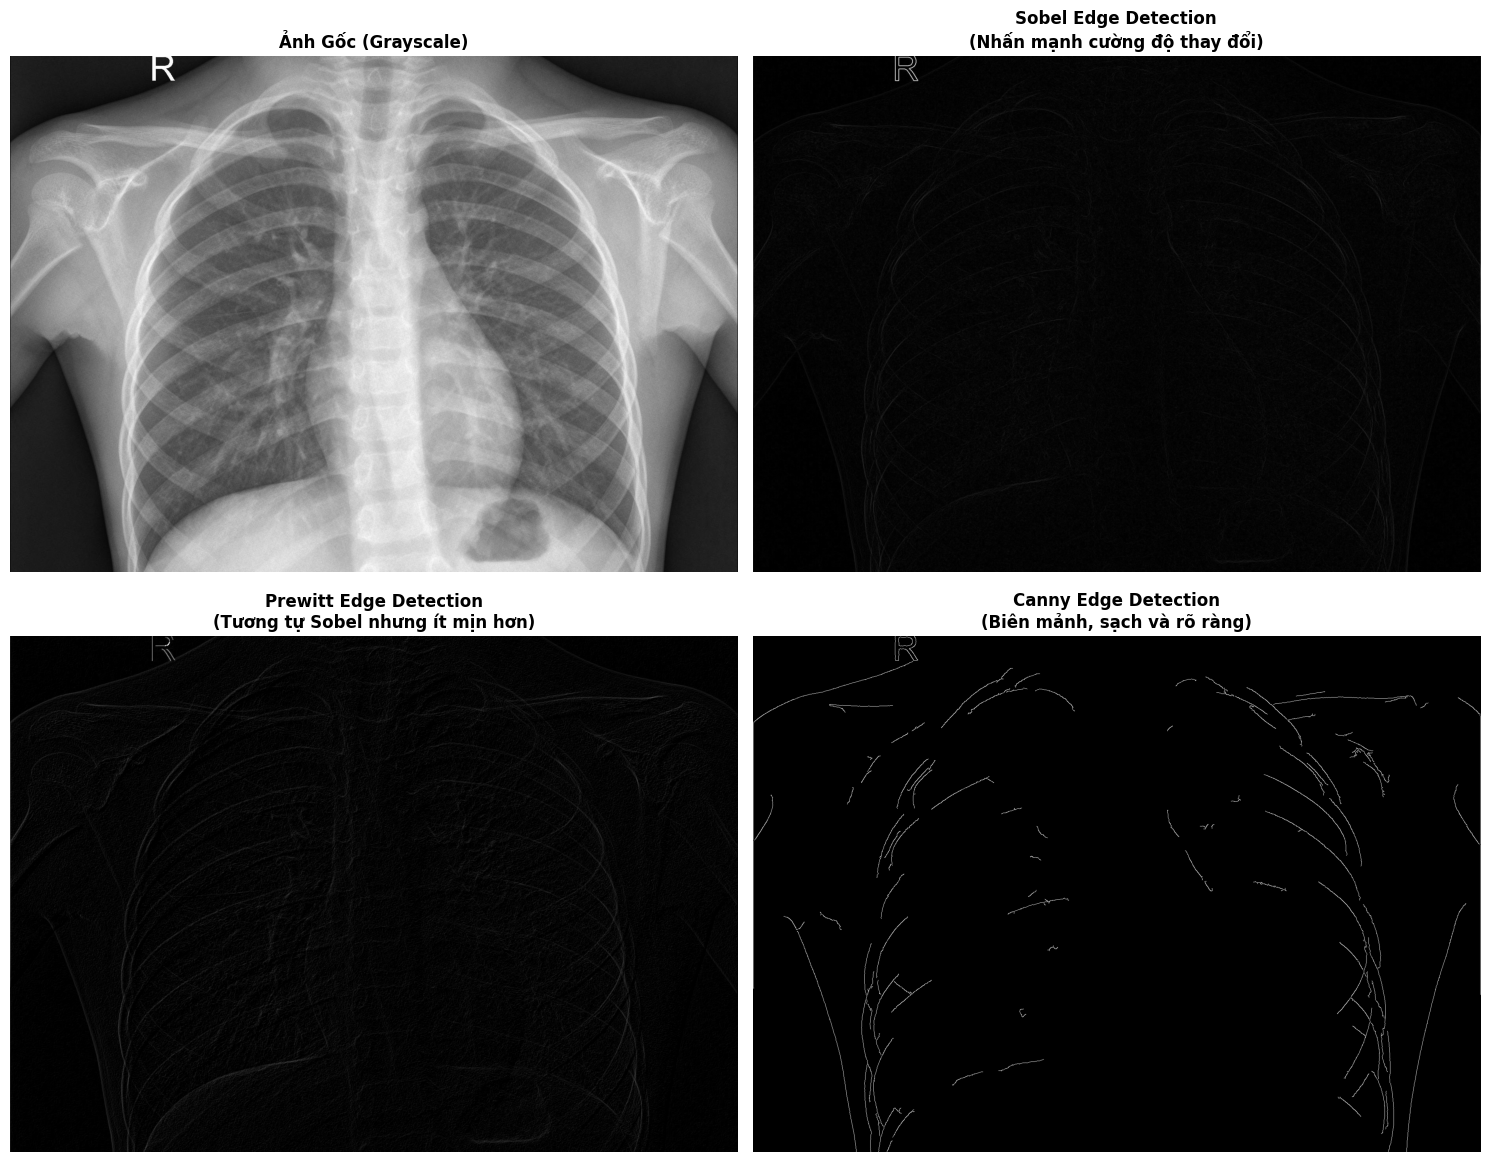

In [24]:
sobel, prewitt, canny = apply_edge_detection(gray_img)

# Trực quan hóa so sánh
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

axes[0, 0].imshow(gray_img, cmap='gray')
axes[0, 0].set_title("Ảnh Gốc (Grayscale)", fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(sobel, cmap='gray')
axes[0, 1].set_title("Sobel Edge Detection\n(Nhấn mạnh cường độ thay đổi)", fontweight='bold')
axes[0, 1].axis('off')

axes[1, 0].imshow(prewitt, cmap='gray')
axes[1, 0].set_title("Prewitt Edge Detection\n(Tương tự Sobel nhưng ít mịn hơn)", fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(canny, cmap='gray')
axes[1, 1].set_title("Canny Edge Detection\n(Biên mảnh, sạch và rõ ràng)", fontweight='bold')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()